# Libraries
Import the core Python libraries used for data loading, analysis, plotting, and modeling.

In [167]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load in Source data
Read the diabetes dataset from the CSV file into a pandas DataFrame so it can be explored and analyzed.

In [168]:
df = pd.read_csv('../data/Diabetes_and_LifeStyle_Dataset_.csv')

In [169]:
display(df.head())

,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,52,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [170]:
display(df.describe().T)



,count,mean,std,min,25%,50%,75%,max
Age,97297.0,50.192699,15.492557,19.00,38.00,51.00,61.00,90.00
alcohol_consumption_per_week,97297.0,2.004543,1.418060,0.00,1.00,2.00,3.00,10.00
physical_activity_minutes_per_week,97297.0,118.942886,84.441920,0.00,57.00,100.00,160.00,833.00
diet_score,97297.0,5.995214,1.780096,0.00,4.80,6.00,7.20,10.00
sleep_hours_per_day,97297.0,6.997708,1.093726,3.00,6.30,7.00,7.70,10.00
screen_time_hours_per_day,97297.0,5.997031,2.469805,0.50,4.30,6.00,7.70,16.80
family_history_diabetes,97297.0,0.219657,0.414017,0.00,0.00,0.00,0.00,1.00
hypertension_history,97297.0,0.250912,0.433540,0.00,0.00,0.00,1.00,1.00
cardiovascular_history,97297.0,0.079067,0.269845,0.00,0.00,0.00,0.00,1.00
bmi,97297.0,25.615093,3.588387,15.00,23.20,25.60,28.00,39.20


In [171]:
df.shape

(97297, 31)

In [172]:
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 97297 entries, 0 to 97296
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 97297 non-null  int64  
 1   gender                              97297 non-null  str    
 2   ethnicity                           97297 non-null  str    
 3   education_level                     97297 non-null  str    
 4   income_level                        97297 non-null  str    
 5   employment_status                   97297 non-null  str    
 6   smoking_status                      97297 non-null  str    
 7   alcohol_consumption_per_week        97297 non-null  int64  
 8   physical_activity_minutes_per_week  97297 non-null  int64  
 9   diet_score                          97297 non-null  float64
 10  sleep_hours_per_day                 97297 non-null  float64
 11  screen_time_hours_per_day           97297 non-null  

None

# Check if there are duplicates
Identify any duplicate rows in the dataset to determine whether duplicate records should be removed before analysis.

In [173]:
duplicates = df[df.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [Age, gender, ethnicity, education_level, income_level, employment_status, smoking_status, alcohol_consumption_per_week, physical_activity_minutes_per_week, diet_score, sleep_hours_per_day, screen_time_hours_per_day, family_history_diabetes, hypertension_history, cardiovascular_history, bmi, waist_to_hip_ratio, systolic_bp, diastolic_bp, heart_rate, cholesterol_total, hdl_cholesterol, ldl_cholesterol, triglycerides, glucose_fasting, glucose_postprandial, insulin_level, hba1c, diabetes_risk_score, diabetes_stage, diagnosed_diabetes]
Index: []

[0 rows x 31 columns]


# Check for missing values
Count missing or null values in each column to understand the completeness of the dataset.

In [174]:
df.isna().sum()

Age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting                       0


## Observation
No missing values were found across all 31 columns. No imputation is required

# Class distribution
Count the number of records per diabetes stage to understand the balance of the dataset.

In [175]:
print(df['diabetes_stage'].value_counts())
print(df['diabetes_stage'].value_counts(normalize=True).mul(100).round(1))

diabetes_stage
Type 2          58163
Pre-Diabetes    31013
No Diabetes      7737
Gestational       267
Type 1            117
Name: count, dtype: int64
diabetes_stage
Type 2          59.8
Pre-Diabetes    31.9
No Diabetes      8.0
Gestational      0.3
Type 1           0.1
Name: proportion, dtype: float64


## Observation
Type 2 accounts for the majority of records at roughly 60%, followed by Pre-Diabetes at 32%. 
No Diabetes represents 8% while Type 1 and Gestational together make up under 0.5% of the 
dataset. This confirms the severe class imbalance that will need to be addressed in modelling.

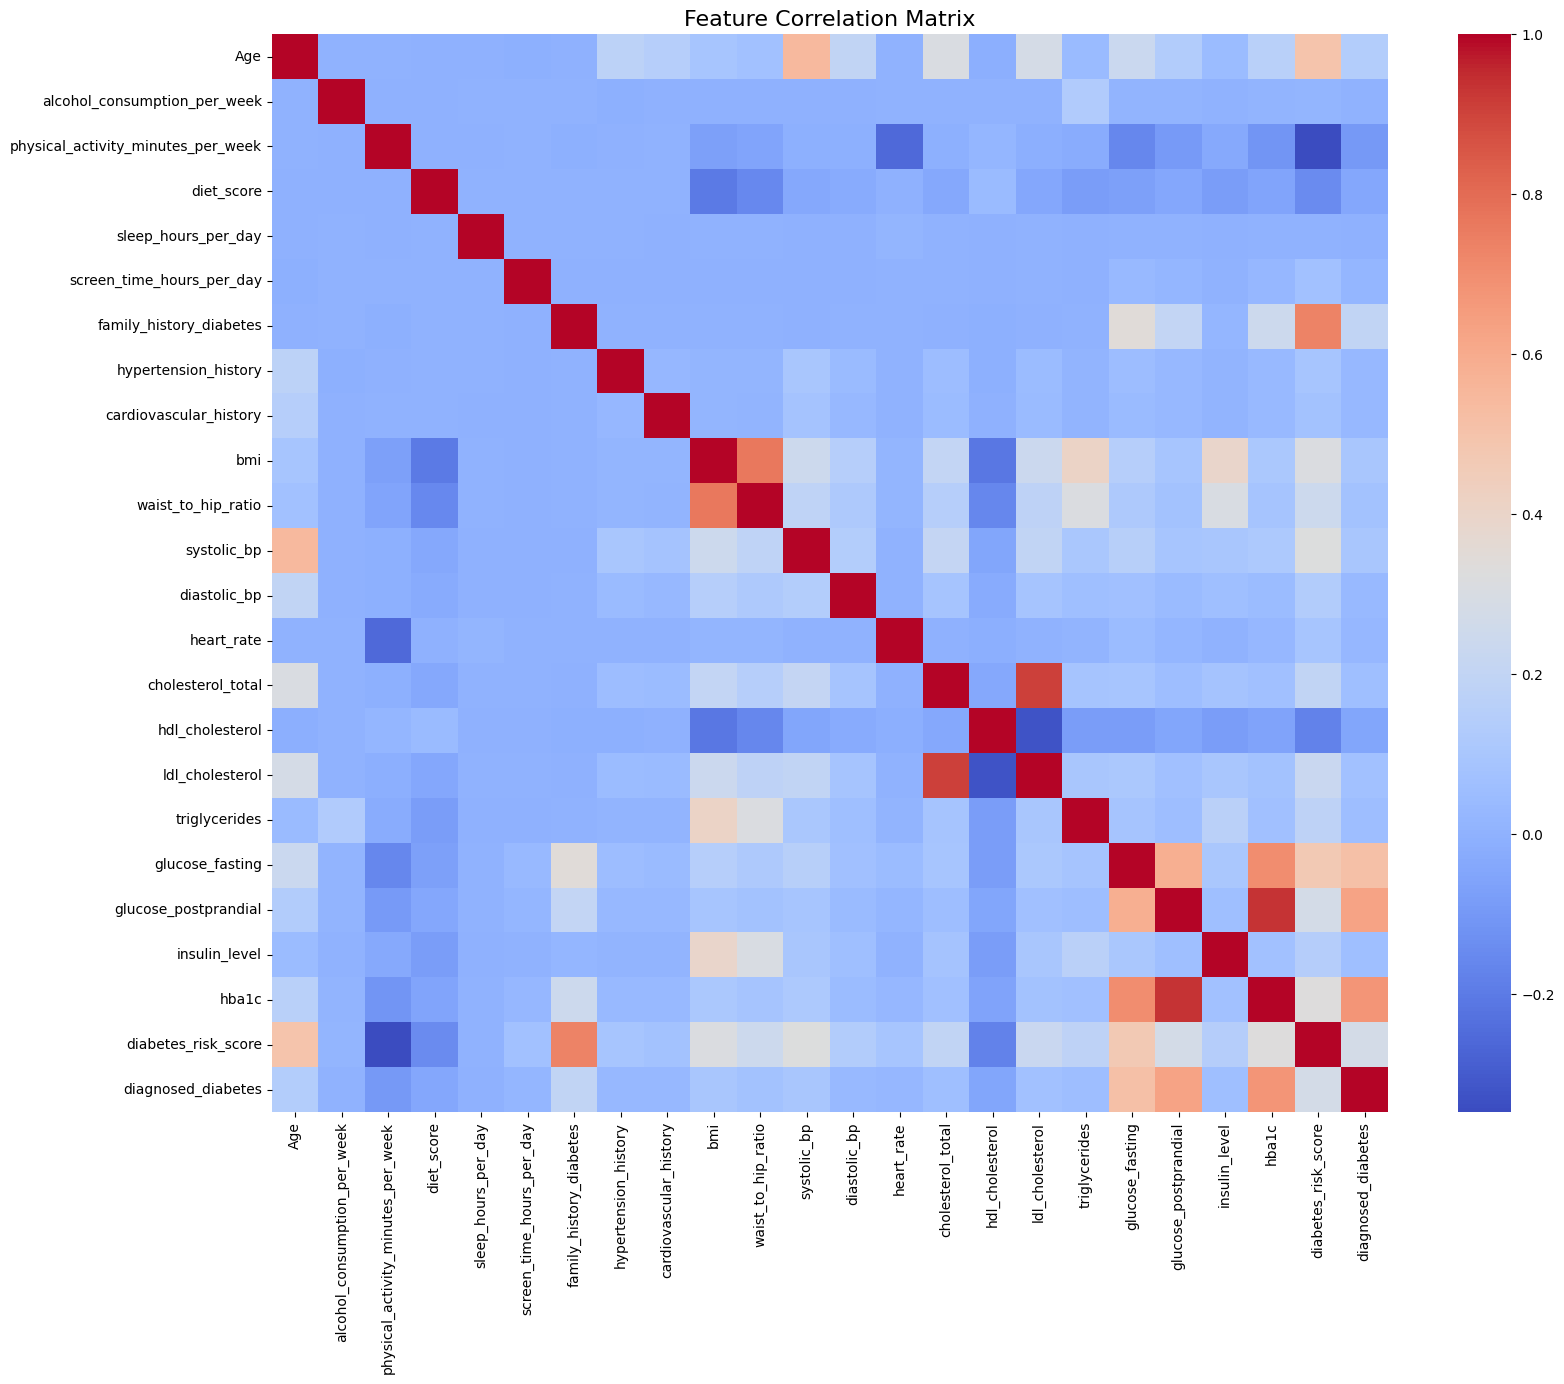

In [176]:

plt.figure(figsize=(18, 14))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm');
plt.title('Feature Correlation Matrix', fontsize=16)
plt.show()

## Observation
The heatmap reveals strong correlations between hba1c, glucose_fasting, and
glucose_postprandial, which are all closely related clinical measures of blood sugar.
diagnosed_diabetes shows a near-perfect correlation with the target, confirming it
must be dropped as a leakage column. BMI shows moderate correlation with glucose
measures. Most lifestyle features such as physical_activity_minutes_per_week and
diet_score show weaker correlations, suggesting they are supporting rather than
primary predictors.

# Leakage discussion and what columns will be dropped
diagnosed_diabetes is a direct binary encoding of the target and will be dropped before modelling to prevent data leakage. diabetes_risk_score appears to be a derived score computed from the target variable and will also be excluded from features. Including either column would result in artificially inflated model performance that would not generalise to unseen patients.

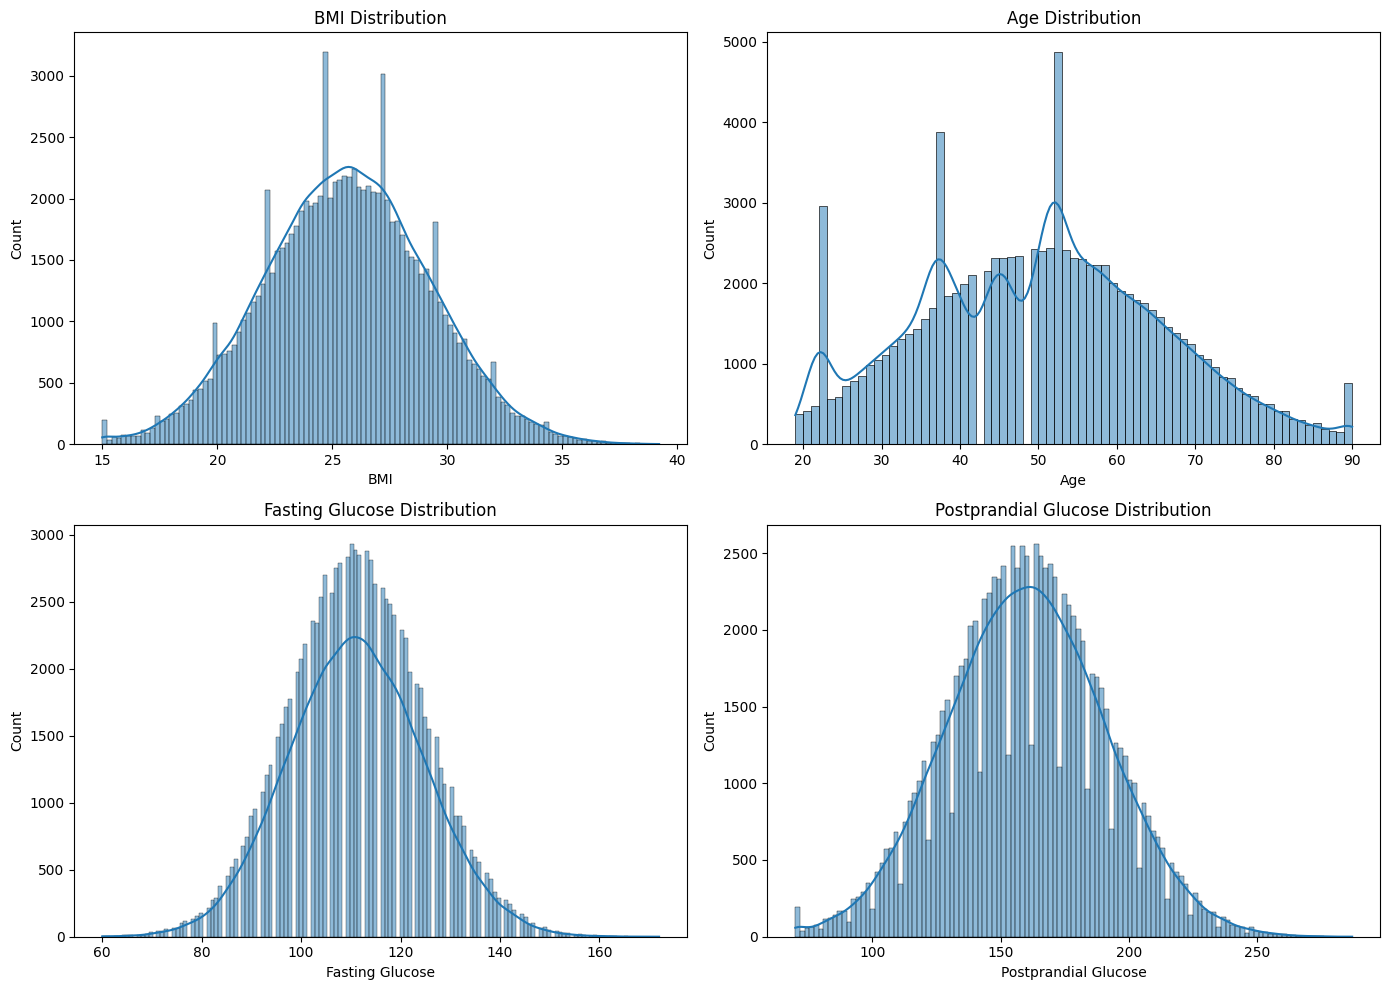

In [177]:
# Plot distributions for key numeric features to inspect their shape and variability.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['bmi'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('BMI Distribution')
axes[0, 0].set_xlabel('BMI')
axes[0, 0].set_ylabel('Count')

sns.histplot(df['Age'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Age Distribution')
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Count')

sns.histplot(df['glucose_fasting'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Fasting Glucose Distribution')
axes[1, 0].set_xlabel('Fasting Glucose')
axes[1, 0].set_ylabel('Count')

sns.histplot(df['glucose_postprandial'], kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Postprandial Glucose Distribution')
axes[1, 1].set_xlabel('Postprandial Glucose')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Observation
BMI shows a roughly normal distribution with a slight right skew, centred around 25–30,
suggesting a mix of healthy-weight and overweight patients in the dataset. Age is fairly
uniformly spread across the adult range with no strong concentration at a particular age
group. Both fasting and postprandial glucose show right-skewed distributions with long
tails at higher values. This is expected given that diabetic patients have elevated
glucose levels that pull the distribution rightward. These skewed features may benefit
from log transformation before modelling, though tree-based models are generally robust
to this.

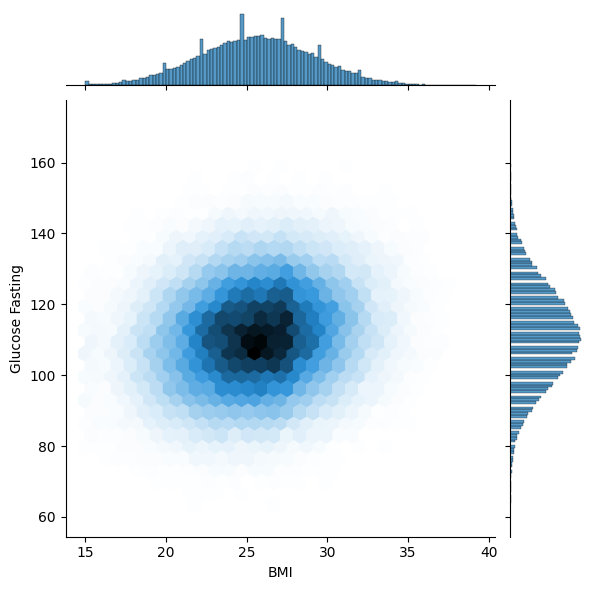

In [178]:
# Visualize the relationship between BMI and fasting glucose using a hexbin-style joint plot.
sns.jointplot(x='bmi', y='glucose_fasting', data=df, kind='hex', gridsize=30)
plt.xlabel('BMI')
plt.ylabel('Glucose Fasting')
plt.show()

## Observation
There is a weak positive relationship between BMI and fasting glucose. Higher BMI
values tend to coincide with higher fasting glucose, but the spread is wide, indicating
BMI alone is not a strong predictor of glucose levels. The density is concentrated in
the BMI range of 20 to 35 and glucose range of 80 to 140, which reflects the majority
Pre-Diabetes and No Diabetes population. The scattered high-glucose points at the top
of the plot correspond to Type 2 patients with poorly controlled blood sugar.

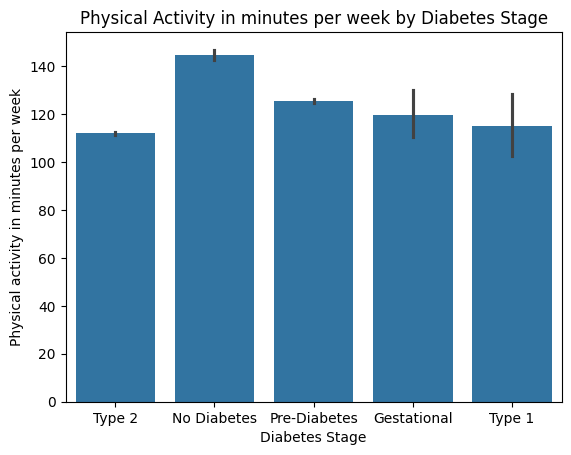

In [179]:
# Compare the average physical activity level across diabetes stages.
sns.barplot(x='diabetes_stage', y='physical_activity_minutes_per_week', data=df)
plt.title('Physical Activity in minutes per week by Diabetes Stage')
plt.xlabel('Diabetes Stage')
plt.ylabel('Physical activity in minutes per week')
plt.show()

## Observation
Patients with No Diabetes show the highest average physical activity levels, while
Type 2 patients show the lowest. This supports the known clinical relationship between
sedentary lifestyle and increased diabetes risk. Pre-Diabetes patients fall between the
two extremes, suggesting that physical activity may be a meaningful intervention point
for this group. Gestational and Type 1 stages should be interpreted cautiously here
given their very small sample sizes of 267 and 117 records respectively.

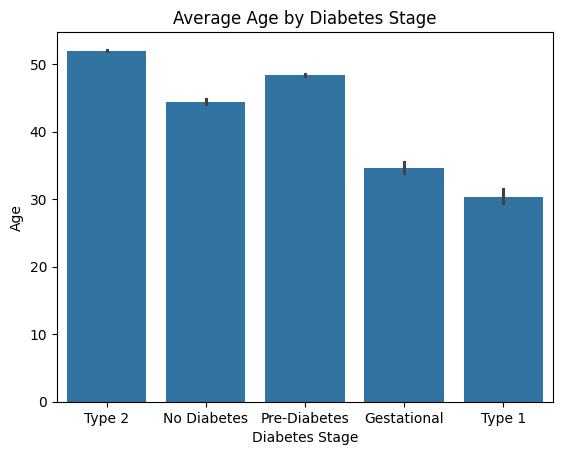

In [180]:
# Compare the average age across diabetes stages.
sns.barplot(x='diabetes_stage', y='Age', data=df)
plt.title('Average Age by Diabetes Stage')
plt.xlabel('Diabetes Stage')
plt.ylabel('Age')
plt.show()

## Observation
Type 2 patients are on average older than all other groups, which aligns with the
well-established link between ageing and insulin resistance. Pre-Diabetes patients are
also older on average than the No Diabetes group. Type 1 patients tend to be younger,
consistent with its classification as a condition that typically presents earlier in
life. Gestational diabetes patients are in the typical reproductive age range. Age is
therefore a meaningful feature for the classifier to distinguish between stages.

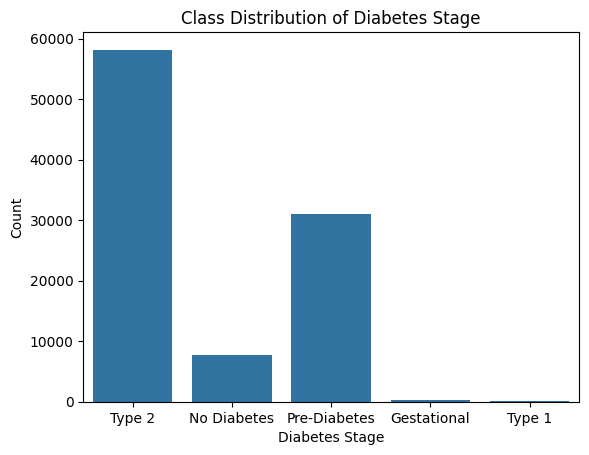

In [181]:
# Count how many records are present in each diabetes stage.
sns.countplot(x='diabetes_stage', data=df)
plt.title('Class Distribution of Diabetes Stage')
plt.xlabel('Diabetes Stage')
plt.ylabel('Count')
plt.show()

## Observation
The dataset is severely imbalanced. Type 2 dominates at approximately 60% of all
records, followed by Pre-Diabetes at 32%. No Diabetes accounts for roughly 8%, while
Type 1 at 117 rows and Gestational at 267 rows are extremely underrepresented. If left
unaddressed, a classifier would likely ignore these minority classes entirely and still
achieve high overall accuracy by defaulting to Type 2. To counter this, all classifiers
in this project will use class_weight='balanced' or equivalent so that minority classes
are given proportionally higher weight during training.

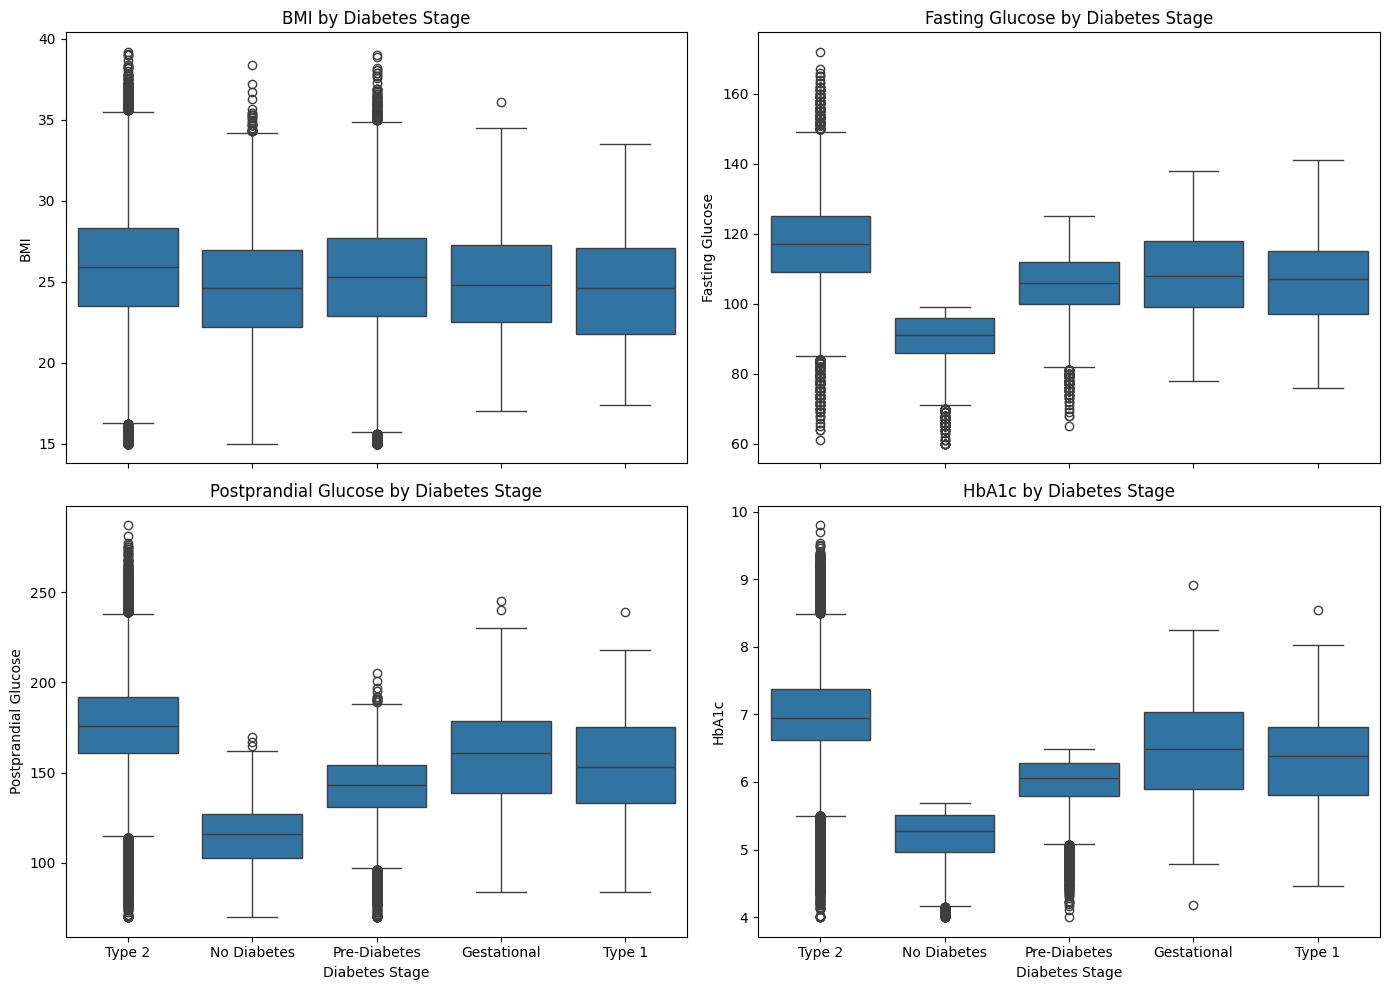

In [182]:
# Compare clinical measures across diabetes stages with multiple boxplots.
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

sns.boxplot(x='diabetes_stage', y='bmi', data=df, ax=axes[0, 0])
axes[0, 0].set_title('BMI by Diabetes Stage')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('BMI')

sns.boxplot(x='diabetes_stage', y='glucose_fasting', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Fasting Glucose by Diabetes Stage')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('Fasting Glucose')

sns.boxplot(x='diabetes_stage', y='glucose_postprandial', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Postprandial Glucose by Diabetes Stage')
axes[1, 0].set_xlabel('Diabetes Stage')
axes[1, 0].set_ylabel('Postprandial Glucose')

sns.boxplot(x='diabetes_stage', y='hba1c', data=df, ax=axes[1, 1])
axes[1, 1].set_title('HbA1c by Diabetes Stage')
axes[1, 1].set_xlabel('Diabetes Stage')
axes[1, 1].set_ylabel('HbA1c')

plt.tight_layout()
plt.show()

## Observation
The boxplots clearly separate the diabetes stages on all four clinical measures. HbA1c
and fasting glucose show the sharpest separation. Type 2 patients have notably higher
medians and wider spreads compared to No Diabetes patients, making these two features
the strongest candidates for classification. Postprandial glucose follows a similar
pattern. BMI also increases from No Diabetes through to Type 2, though with more
overlap between groups, suggesting it is a supporting rather than primary feature.
The small boxes for Type 1 and Gestational reflect their limited sample sizes rather
than low variability. Overall, the clinical biomarkers are strong discriminators between
stages, while lifestyle features like BMI play a secondary role.